In [1]:
from PIL import Image, ImageDraw # type: ignore
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
import os # type: ignore
import json # type: ignore
import torch # type: ignore
import torchvision.transforms as transforms # type: ignore
from torch.utils.data import Dataset # type: ignore
from tqdm import tqdm  # type: ignore
import random # type: ignore
import torchvision # type: ignore
import torch_directml # type: ignore

In [2]:
# Device declaration
'''
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print('cuda')
elif torch_directml.is_available():
    device = torch_directml.device(0)
    print(torch_directml.device_name(0))
else:
    device = torch.device('cpu')
    print('cpu')
'''
device = torch.device('cpu')
print(device)

cpu


In [3]:
# Create Data Processor Class
class DataProcessorr:
    def __init__(self, cnn_output=20,
                 base_path='./resources/tt100k_2021/other/',
                 annotations_path='./resources/tt100k_2021/annotations_all.json',
                 save_path='./resources/tt100k_2021/train/',
                 labels_path='./resources/tt100k_2021/labels_all.json',):
        self.CNN_output = cnn_output # We have a 20 * 20 grid after CNN layers
        self.nums_per_pixel = 5 # For each pixel in the grid we have (probability, x, y, width, height)
        self.base_path = base_path # Base path for images
        self.annotations_path = annotations_path # Path for annotations
        self.save_path = save_path # Path to save processed data
        self.labels_path = labels_path
    def create_labels(self, image, objects):
        # Base tensor, which would be transformed into a label tensor
        labels = torch.zeros([self.CNN_output, self.CNN_output, self.nums_per_pixel])
        size = image.size
        for bbox in objects: # For each sign on the picture
            xmin = bbox['xmin']
            ymin = bbox['ymin']
            xmax = bbox['xmax']
            ymax = bbox['ymax']
            x_center = int(xmin + xmax) // 2 # Sign center coordinate x
            y_center = int(ymin + ymax) // 2 # Sign center coordinate x
            block_x = int(self.CNN_output / size[0] * x_center) # Block id (x)
            block_y = int(self.CNN_output / size[1] * y_center) # Block id (y)
            # Clamp values (0, CNN_output)
            block_x = max(0, block_x)
            block_y = max(0, block_y)
            block_x = min(self.CNN_output - 1, block_x)
            block_y = min(self.CNN_output - 1, block_y)
            # Relative coords
            x_center = (x_center % (size[0] / self.CNN_output)) / (size[0] / self.CNN_output)
            y_center = (y_center % (size[1] / self.CNN_output)) / (size[1] / self.CNN_output)
            width = (xmax - xmin) / size[0]
            height = (ymax - ymin) / size[1]
            labels[block_y, block_x] = torch.tensor([1, x_center, y_center, width, height])
        return labels.view(-1)
    def get_tiles(self, image, objects):
        # Split image into a 2 * 2 image grid
        tiles = [[1 for _ in range(2)] for _ in range(2)]
        signs = [[list() for _ in range(2)] for _ in range(2)]
        labels = [[1 for _ in range(2)] for _ in range(2)]
        size = image.size
        half_w = size[0] // 2
        half_h = size[1] // 2
        # Get subimages
        tiles[0][0] = (image.crop((0, 0, half_w, half_h)))
        tiles[0][1] = (image.crop((half_w, 0, size[0], half_h)))
        tiles[1][0] = (image.crop((0, half_h, half_w, size[1])))
        tiles[1][1] = (image.crop((half_w, half_h, size[0], size[1])))
        for bbox in objects: # For each sign on the whole image
            xmin = float(bbox['bbox']['xmin'])
            ymin = float(bbox['bbox']['ymin'])
            xmax = float(bbox['bbox']['xmax'])
            ymax = float(bbox['bbox']['ymax'])
            x_center = (xmin + xmax) / 2
            y_center = (ymin + ymax) / 2
            tx = 1 if x_center >= half_w else 0
            ty = 1 if y_center >= half_h else 0
            offset_x = tx * half_w
            offset_y = ty * half_h
            # Transform coordinates (depends on the tile id)
            new_xmin = max(0, min(half_w, xmin - offset_x))
            new_xmax = max(0, min(half_w, xmax - offset_x))
            new_ymin = max(0, min(half_h, ymin - offset_y))
            new_ymax = max(0, min(half_h, ymax - offset_y))
            signs[ty][tx].append({'xmin': new_xmin,
                                  'ymin': new_ymin,
                                  'xmax': new_xmax,
                                  'ymax': new_ymax})
        # Fill labels
        for i in range(2):
            for j in range(2):
                labels[i][j] = self.create_labels(tiles[i][j], signs[i][j])
        return tiles, labels, signs
    def process_all(self):
        save_index = 0
        labels_json = {} # New labels
        with open(self.annotations_path, 'r') as j:
            annotations = json.load(j) # Old labels
        for obj in tqdm(os.listdir(self.base_path)):
            id = obj.split('.')[0] # Img id
            img = Image.open(self.base_path + obj).convert('RGB')
            # Get tiles and new labels
            if not annotations['imgs'].get(id):
                continue
            tiles, labels, signs = self.get_tiles(img, annotations['imgs'][id]['objects'])
            # Flatten tiles and labels lists and save
            tiles = [item for sublist in tiles for item in sublist]
            labels = [item for sublist in labels for item in sublist]
            signs = [item for sublist in signs for item in sublist]
            for j in range(4):
                if len(signs[j]) == 0 and random.random() > 0.3:
                    continue
                tiles[j].save(f'{self.save_path}{save_index}.jpg')
                labels_json[save_index] = labels[j].tolist()
                save_index += 1
        with open(self.labels_path, 'w') as j:
            json.dump(labels_json, j)

In [41]:
# Process all images
# processor = DataProcessorr()
# processor.process_all()

100%|██████████| 16811/16811 [13:30<00:00, 20.74it/s]


To prevent storage leakage, I'll delete the 'other' directory and old labels json, 'cause now we have another folder 'train' with this images and the new labels json

In [6]:
# Let's check if we have correct labels
# Load nesseccary data
with open('./resources/tt100k_2021/labels_all.json', 'r') as j:
    labels_json_vis = json.load(j)

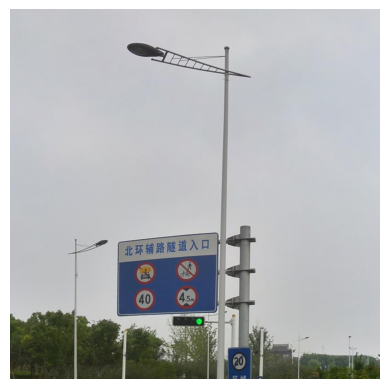

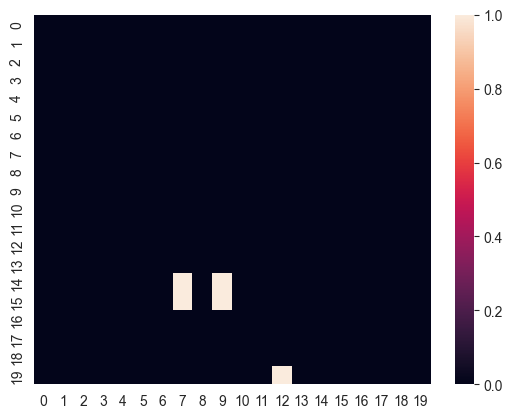

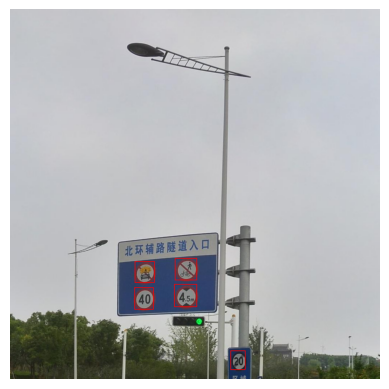

In [3]:
# Visualize the data
id_to_check = 13
img_vis = Image.open(f'./resources/tt100k_2021/train/{id_to_check}.jpg') # Image id=13
labels_vis = labels_json_vis[str(id_to_check)] # Labels id=13
labels_vis = torch.tensor(labels_vis).view(20, 20, 5)
# Image
plt.axis('off')
plt.imshow(img_vis)
plt.show()
# Confidence
sns.heatmap(labels_vis[:, :, 0])
plt.show()
# Borders
draw = ImageDraw.Draw(img_vis)
for i in range(20):
    for j in range(20):
        if labels_vis[i][j][0] == 0:
            continue
        else:
            size_vis = img_vis.size
            x_center_vis = (j + labels_vis[i][j][1]) * (size_vis[0] // 20)
            y_center_vis = (i + labels_vis[i][j][2]) * (size_vis[1] // 20)
            x_min_vis = x_center_vis - labels_vis[i][j][3] * size_vis[0] // 2
            x_max_vis = x_center_vis + labels_vis[i][j][3] * size_vis[0] // 2
            y_min_vis = y_center_vis - labels_vis[i][j][4] * size_vis[1] // 2
            y_max_vis = y_center_vis + labels_vis[i][j][4] * size_vis[1] // 2
            draw.line((x_min_vis, y_min_vis, x_min_vis, y_max_vis), 'red', width=2)
            draw.line((x_min_vis, y_min_vis, x_max_vis, y_min_vis), 'red', width=2)
            draw.line((x_max_vis, y_min_vis, x_max_vis, y_max_vis), 'red', width=2)
            draw.line((x_min_vis, y_max_vis, x_max_vis, y_max_vis), 'red', width=2)
plt.axis('off')
plt.imshow(img_vis)
plt.show()

In [4]:
# Now we can create a Dataset class
class TT100KDataset(torch.utils.data.Dataset):
    def __init__(self, base_path='./resources/tt100k_2021/train',
                 labels_path='./resources/tt100k_2021/labels_all.json',
                 transformer=None):
        super().__init__()
        self.base_path = base_path # Base path to all the pictures
        if transformer is None: # Redeclare image transformer if it is None
            self.transformer = transforms.Compose([
                transforms.Resize((640, 640)),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transformer = transformer
        with open(labels_path, 'r') as j:
            self.labels_dict = json.load(j)
    def __len__(self): # Dataset length
        return len(self.labels_dict)
    def __getitem__(self, idx): # Get image and labels 'on the fly'
        img = Image.open(f'{self.base_path}/{idx}.jpg')
        labels = torch.tensor(self.labels_dict[f'{idx}'], dtype=torch.float32)
        img = self.transformer(img)
        return img, labels

Now, as we've done data preparation, we can move to model construction

In [5]:
# CNN Class (based on the Tencent paper)
class CNN(torch.nn.Module):
    def __init__(self, output_channels=512):
        super().__init__()
        # Hyperparameters
        self.input_channel = 3
        self.output_channels = output_channels
        # Layers
        self.layer1 = self.create_layer(self.input_channel, 32)
        self.layer2 = self.create_layer(32, 64)
        self.layer3 = self.create_layer(64, 128)
        self.layer4 = self.create_layer(128, 256)
        self.layer5 = self.create_layer(256, self.output_channels)
    @staticmethod
    def create_layer(in_channels, out_channels):
        return torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=in_channels, # Convolutional filter
                            out_channels=out_channels,
                            kernel_size=3,
                            stride=1,
                            padding=1),
            torch.nn.BatchNorm2d(num_features=out_channels), # Batch normalization
            torch.nn.ReLU(), # Actiation function
            torch.nn.MaxPool2d(kernel_size=2, # Max pooling
                               stride=2),
            torch.nn.Dropout2d(p=0.25) # Dropout
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        return x

In [6]:
# Positional Eencoding Class
class Embedding(torch.nn.Module):
    def __init__(self, num_tokens=20*20, embedding_size=256):
        super().__init__()
        # For each picture we have shape=(20, 20, 256) tensor of features. We also need to add dim for batch size
        self.positional_embedding = torch.nn.Parameter(torch.randn(1, num_tokens, embedding_size))
    def forward(self, x):
        return x + self.positional_embedding

In [7]:
# Multihed Attention Class (Based on ViT)
# We do not have the mask here 'cause our predictions do not depend on previous predictoins
class MultiheadAttention(torch.nn.Module):
    def __init__(self, num_heads=8, embed_dim=256):
        super().__init__()
        self.num_heads = num_heads # Number of attention heads
        self.head_dim = embed_dim // self.num_heads # Dimensionality of each head
        assert embed_dim % self.num_heads == 0 # Check if possible
        self.q = torch.nn.Linear(embed_dim, embed_dim) # Matrix to get Query for all heads
        self.k = torch.nn.Linear(embed_dim, embed_dim) # Matrix to get Keys for all heads
        self.v = torch.nn.Linear(embed_dim, embed_dim) # Matrix to get Values for all heads
        self.out = torch.nn.Linear(embed_dim, embed_dim) # Final output projection layer
    def forward(self, x):
        batch_size, seq_len, embed_dim = x.size() # x: shape=(batch_size, seq_len=400, embed_dim=256)
        # Get Queries, Keys, Values for all heads
        q = self.q(x).view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        k = self.k(x).view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        v = self.v(x).view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        # q, k, v: shape=(batch_size, num_heads=8, seq_len=400, head_dim=32)
        # Get weights for context vector
        attention_logits = torch.matmul(q, k.permute(0, 1, 3, 2)) / (self.head_dim ** 0.5)
        attention_weights = torch.nn.functional.softmax(attention_logits, dim=-1)
        # Get context vector
        attention = torch.matmul(attention_weights, v).permute(0, 2, 1, 3).contiguous().view(batch_size, seq_len, embed_dim)
        # Final projection
        attention = self.out(attention)
        return attention

In [8]:
# Feed Forward Class
class FeedForward(torch.nn.Module):
    def __init__(self, embed_dim=256, expansion=4):
        super().__init__()
        self.fc1 = torch.nn.Linear(embed_dim, expansion * embed_dim) # Expand output (256 -> 1024)
        self.gelu = torch.nn.GELU()
        self.fc2 = torch.nn.Linear(expansion * embed_dim, embed_dim) # Back to embed_dim (1024 -> 256)
        self.dropout = torch.nn.Dropout(p=0.1)
    def forward(self, x):
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

In [9]:
# Transformer Block Class
class TransformerBlock(torch.nn.Module):
    def __init__(self, num_heads=8, embed_dim=256, expansion=4, normalized_shape=256):
        super().__init__()
        self.ln1 = torch.nn.LayerNorm(normalized_shape=normalized_shape)
        self.multihead_attention = MultiheadAttention(num_heads=num_heads, embed_dim=embed_dim)
        self.ln2 = torch.nn.LayerNorm(normalized_shape=normalized_shape)
        self.feed_forward = FeedForward(embed_dim=embed_dim, expansion=expansion)
    def forward(self, x):
        # Transformer architecture with MHA, FF, LN and ResNet parts
        residual = x
        x = self.ln1(x)
        x = self.multihead_attention(x)
        x = x + residual
        residual = x
        x = self.ln2(x)
        x = self.feed_forward(x)
        x = x + residual
        return x

In [10]:
# Actual Sigh Detection Model
class SignDetectionModel(torch.nn.Module):
    def __init__(self, output_channels=512, num_heads=8, embed_dim=256, expansion=4, normalized_shape=256, num_transformer_layers=8):
        super().__init__()
        self.tiles = 20
        self.items_per_tile = 5
        self.output_channels = output_channels
        self.CNN = CNN(output_channels=output_channels)
        self.transformer = torch.nn.Sequential(
            *[TransformerBlock(num_heads=num_heads,
                               embed_dim=embed_dim,
                               expansion=expansion,
                               normalized_shape=normalized_shape) for _ in range(num_transformer_layers)]
        )
        self.CNN_projection = torch.nn.Linear(output_channels, embed_dim)
        self.embedding = Embedding(num_tokens=self.tiles * self.tiles,
                                   embedding_size=embed_dim)
        self.head = torch.nn.Linear(in_features=embed_dim,
                                    out_features=self.items_per_tile)
    def forward(self, x):
        # x: shape=(batch_size, output_channels=512, tiles=20, tiles=20)
        x = self.CNN(x)
        # transform x to shape=(batch_size, tiles=20, tiles=20, output_channels=512)
        x = x.permute(0, 2, 3, 1).view(-1, self.tiles * self.tiles, self.output_channels)
        # x: shape=(batch_size, tiles^2=400, output_channel=512)
        x = self.CNN_projection(x)
        # x: shape=(batch_size, tiles^2=400, embed_dim=256)
        # Add positional embedding
        x = self.embedding(x)
        # Transformer
        x = self.transformer(x)
        # Regression head
        x = self.head(x)
        return x

In [11]:
# Custom Loss Class
class LossFN(torch.nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, predictions, labels):
        # Reshape predictions and labels to ensure
        predictions = predictions.view(-1, 20 * 20, 5)
        labels = labels.view(-1, 20 * 20, 5)
        # Get a mask to calculate loss only for p != 0
        labels_coords_mask = (labels[:, :, 0] != 0).bool().unsqueeze(-1).expand_as(predictions[:, :, 1:])
        # BCE loss with logits for p
        p_loss = torch.nn.functional.binary_cross_entropy_with_logits(predictions[:, :, 0], labels[:, :, 0])
        # Smooth L1 loss for (x, y, w, h)
        if labels_coords_mask.sum() == 0:
            xywh_loss = torch.tensor(0.0)
        else:
            xywh_loss = torch.nn.functional.smooth_l1_loss(predictions[:, :, 1:][labels_coords_mask],
                                                           labels[:, :, 1:][labels_coords_mask])
        # Weighted sum of losses
        return p_loss + 5 * xywh_loss

Train and evaluate functions

In [12]:
# Function to validate model's confidence accuracy
def validate(data_loader, model):
    with torch.no_grad():
        model.eval()
        pos_confidence, neg_confidence = 0.0, 0.0
        pos_count, neg_count = 0, 0
        # For each image we calculate predictions
        # For each prediction we calculate confidence accuracy
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            predictions = torch.sigmoid(model(images))[:, :, 0]
            labels_coords_mask = torch.tensor((labels[:, :, 0] != 0), dtype=torch.bool).to(device)
            # There can be 0 signs on the image. Need to check to prevent NaN
            if labels_coords_mask.sum() != 0:
                # Sum of the confidences across positive pixels
                pos_confidence += predictions[labels_coords_mask].sum().item()
                pos_count += labels_coords_mask.sum().item()
            # Sum of the confidences across negative pixels
            neg_confidence += predictions[~labels_coords_mask].sum().item()
            neg_count += (~labels_coords_mask).sum().item()
    return pos_confidence / (pos_count + 1e-6), neg_confidence / (neg_count + 1e-6)

In [13]:
# Function to train the model for a single epoch
def train_epoch(data_loader, model, optimizer, criterion):
    model.train()
    running_loss = 0.0
    tqdm_loader = tqdm(data_loader)
    # Standart learning cycle
    for i, (images, labels) in enumerate(tqdm_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        # For each 1000's iteration, we'll see the average loss
        if (i + 1) % 100 == 0:
            tqdm_loader.set_postfix(loss=f'{running_loss / (i + 1):.4f}')
    return running_loss / len(data_loader)

In [14]:
# Function to train the model from last_epoch to num_epochs
def train(data_loader, model, optimizer, criterion, scheduler, num_epochs, last_epoch):
    # For each epoch perform learning and validation
    for epoch in range(last_epoch, num_epochs):
        avg_loss = train_epoch(data_loader, model, optimizer, criterion)
        scheduler.step()
        pos_confidence, neg_confidence = validate(data_loader, model)
        print(f'Epoch: {epoch + 1}/{num_epochs}')
        print(f'Average loss: {avg_loss:.4f}')
        print(f'Positive confidence: {pos_confidence:.4f}')
        print(f'Negative confidence: {neg_confidence:.4f}')
        print()

        if (epoch + 1) % 5 == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'num_epochs': num_epochs
            }
            torch.save(checkpoint, f'./resources/models/model{epoch + 1}.pth')

Object declaration

In [15]:
# Create objects of necessary classes
last_checkpoint = None # Need to be a path:str if we want to load the existing model
last_epoch = 0
num_epochs = 50
dataset = TT100KDataset()
data_loader = torch.utils.data.DataLoader(dataset=dataset,
                                          batch_size=10,
                                          shuffle=True,
                                          pin_memory=True)
model = SignDetectionModel().to(device)
criterion = LossFN().to(device)
optimizer = torch.optim.SGD(model.parameters(),
                            lr=1e-4,
                            momentum=0.9,
                            weight_decay=0.01)
scheduler_1 = torch.optim.lr_scheduler.LinearLR(optimizer,
                                                start_factor=0.1,
                                                end_factor=1.0,
                                                total_iters=5)
scheduler_2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer,
                                                                 T_0=10,
                                                                 T_mult=2,
                                                                 eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer,
                                                  schedulers=[scheduler_1, scheduler_2],
                                                  milestones=[5])
# Load the existing model if needed
if last_checkpoint is not None:
    checkpoint = torch.load(f'./resources/models/{last_checkpoint}.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    last_epoch = checkpoint['epoch']
    num_epochs = checkpoint['num_epochs']

Training

In [16]:
# Get the training done
train(data_loader, model, optimizer, criterion, scheduler, num_epochs, last_epoch)

  6%|▌         | 125/2194 [11:20<3:07:44,  5.44s/it, loss=2.5415]


KeyboardInterrupt: 